In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv('/content/core_dataset.csv', low_memory=False)

df = df[df["label"] != "label"]
df = df[df["activity"] != "activity"]

# 1. Перевіряємо розмір
print("Shape:", df.shape)

# 2. Перетворюємо числові колонки
numeric_cols = [col for col in df.columns if col not in ["label", "activity"]]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 3. Замінюємо inf на NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 4. Дивимось пропуски
missing = df.isnull().mean().sort_values(ascending=False)
print("\nMissing ratio:")
print(missing)

# 5. Дивимось типи після конвертації
print("\nDtypes:")
print(df.dtypes)

# 6. Дивимось класи
print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nActivity distribution:")
print(df["activity"].value_counts())

Shape: (160153, 16)

Missing ratio:
duration                  0.0
packets_count             0.0
payload_bytes_mean        0.0
payload_bytes_std         0.0
payload_bytes_skewness    0.0
active_mean               0.0
active_std                0.0
active_skewness           0.0
idle_mean                 0.0
idle_std                  0.0
idle_skewness             0.0
bytes_rate                0.0
packets_rate              0.0
down_up_rate              0.0
label                     0.0
activity                  0.0
dtype: float64

Dtypes:
duration                  float64
packets_count               int64
payload_bytes_mean        float64
payload_bytes_std         float64
payload_bytes_skewness    float64
active_mean               float64
active_std                float64
active_skewness           float64
idle_mean                 float64
idle_std                  float64
idle_skewness             float64
bytes_rate                float64
packets_rate              float64
down_up_rate      

In [ ]:
# Залишаємо активності, які краще відповідають cloud/session behavior
keep_activities = [
    "Suspicious",

    "Benign-Systemic",
    "Benign-Web_Browsing_HTTP-S",
    "Benign-SSH",
    "Benign-Email-Send",
    "Benign-Email-Receive",
    "Benign-FTP",
    "Benign",
    # "Benign-Telnet",  # можна не брати, бо всього 4 рядки

    "Attack-TCP-BYPass-V1",
    "Attack-TCP-Control",
]

df_semantic = df[df["activity"].isin(keep_activities)].copy()

print("Original shape:", df.shape)
print("Filtered shape:", df_semantic.shape)

print("\nLabel distribution:")
print(df_semantic["label"].value_counts())

print("\nActivity distribution:")
print(df_semantic["activity"].value_counts())

Original shape: (160153, 16)
Filtered shape: (109426, 16)

Label distribution:
label
Benign        63330
Suspicious    38417
Attack         7679
Name: count, dtype: int64

Activity distribution:
activity
Suspicious                    38417
Benign-Systemic               38354
Benign-Web_Browsing_HTTP-S    22212
Attack-TCP-BYPass-V1           4260
Attack-TCP-Control             3419
Benign-SSH                     1051
Benign-Email-Send               663
Benign                          604
Benign-Email-Receive            315
Benign-FTP                      131
Name: count, dtype: int64


In [ ]:
print(df_semantic["label"].value_counts(normalize=True) * 100)

label
Benign        57.874728
Suspicious    35.107744
Attack         7.017528
Name: proportion, dtype: float64


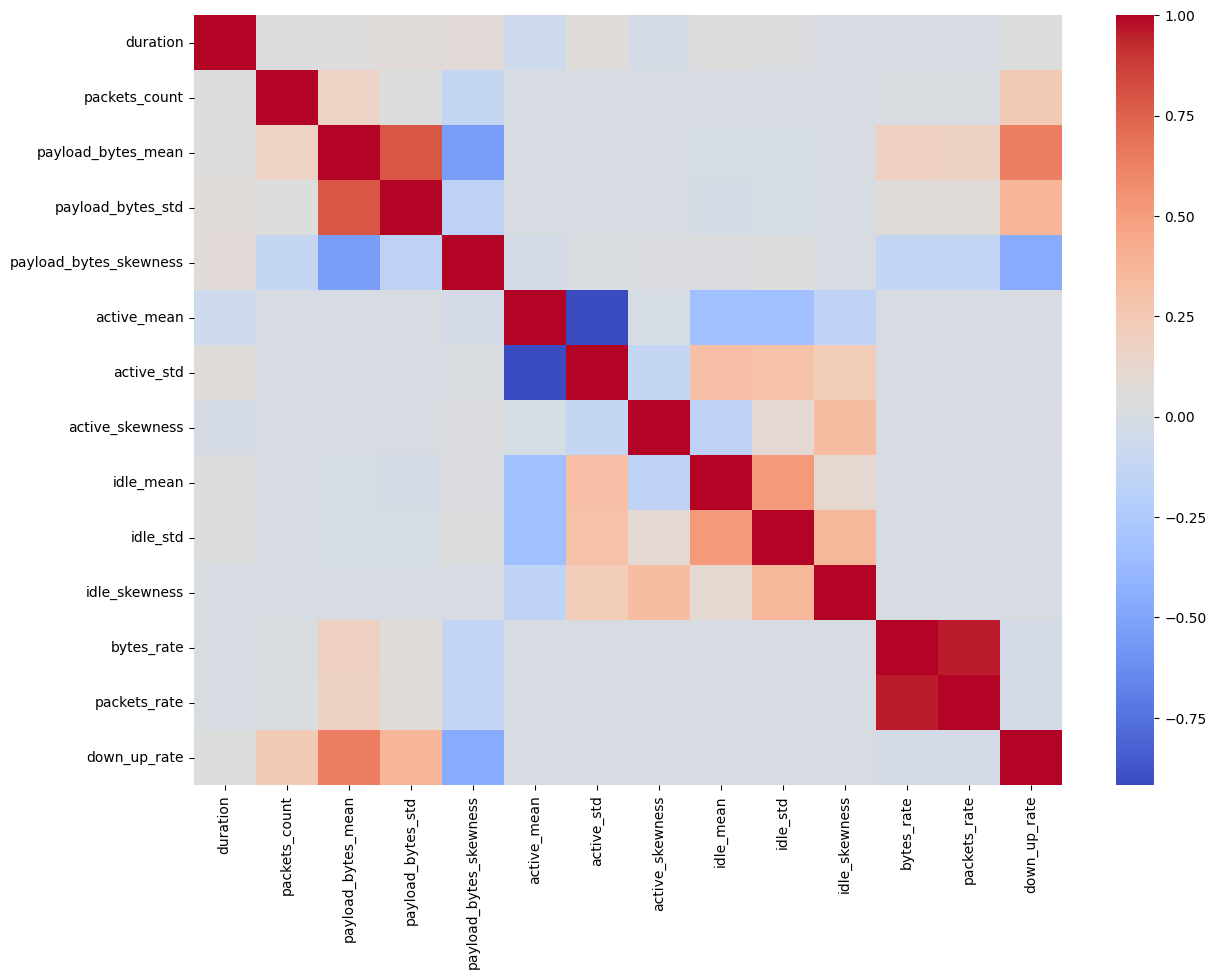

In [ ]:
corr = df_semantic.corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

bytes_rate -- швидкість передачі байтів у потоці

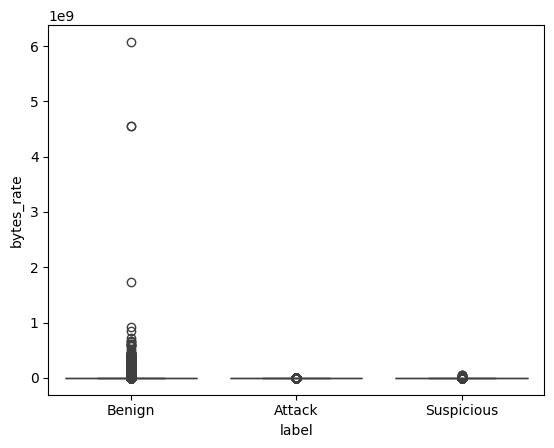

In [ ]:
sns.boxplot(data=df_semantic, x="label", y="bytes_rate")
plt.show()

Без log-transform фіча непридатна для нормального аналізу

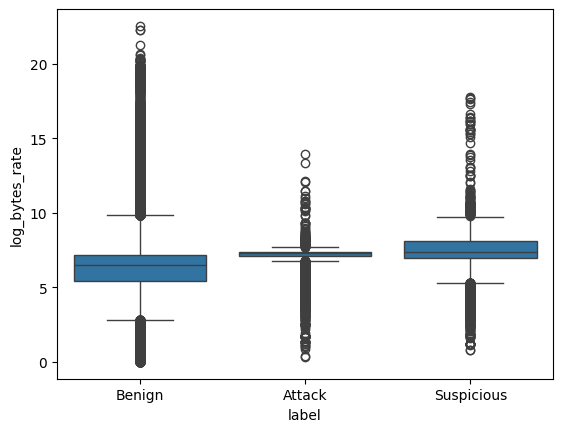

In [ ]:
df_semantic["log_bytes_rate"] = np.log1p(df_semantic["bytes_rate"])

sns.boxplot(data=df_semantic, x="label", y="log_bytes_rate")
plt.show()

| Attack | Suspicious | Benign |
|---|---|---|
|Дуже вузький Distribution|Median вища|Widest Distribution|
|Low Variance|Variance більша|Найбільше extreme cases|
|Концентрується біля ~7


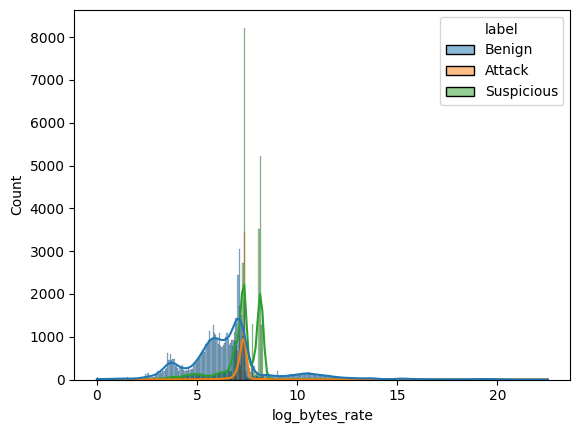

In [ ]:
sns.histplot(
    data=df_semantic,
    x="log_bytes_rate",
    hue="label",
    kde=True
)
plt.show()

*   Attack -> Narrow Spike
*   Suspicious -> Shifted Distribution
*   Benign -> Multimodal Structure

packets_rate -- це швидкість передачі пакетів даних

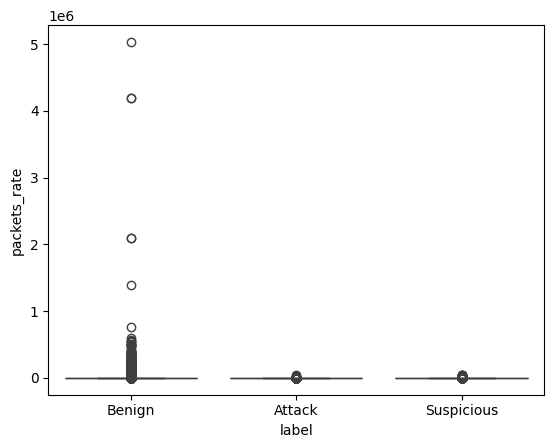

In [ ]:
sns.boxplot(data=df_semantic, x="label", y="packets_rate")
plt.show()

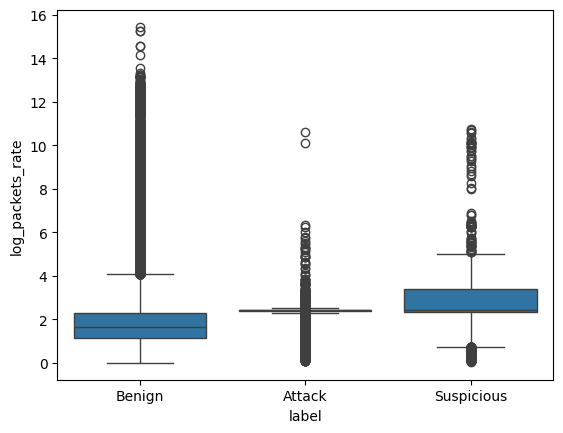

In [ ]:
df_semantic["log_packets_rate"] = np.log1p(df_semantic["packets_rate"])

sns.boxplot(data=df_semantic, x="label", y="log_packets_rate")
plt.show()

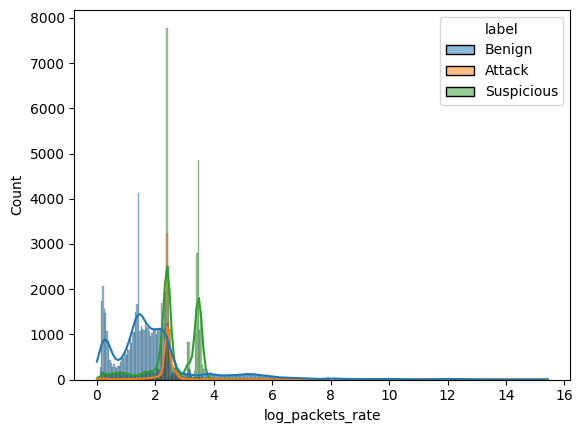

In [ ]:
sns.histplot(
    data=df_semantic,
    x="log_packets_rate",
    hue="label",
    kde=True
)
plt.show()

З аналізу цієї фічі видно, що вона майже повністю дублює попередню, тому лишаємо тільки bytes_rate, оскільки вона більш переносима і значима

duration -- тривалість підключення

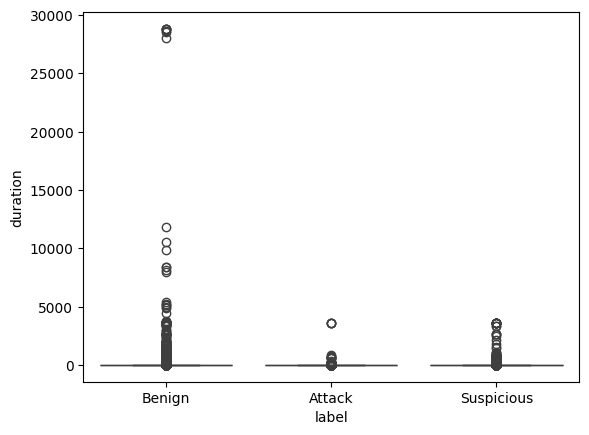

In [ ]:
sns.boxplot(data=df_semantic, x="label", y="duration")
plt.show()

Знову бачимо heavy-tails розподіли з великою кількістю аномалій і стиснутими центрами, тому застосовуємо log-transform

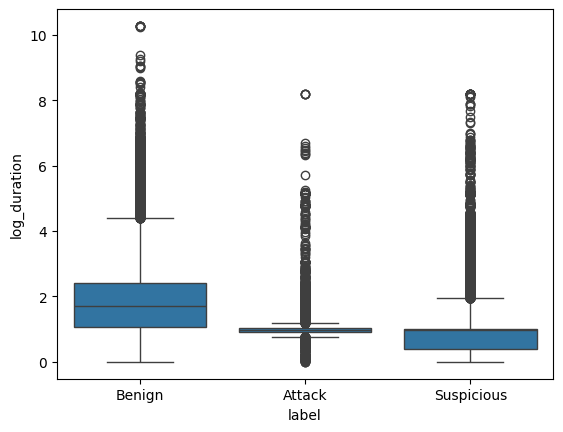

In [ ]:
df_semantic["log_duration"] = np.log1p(df_semantic["duration"])

sns.boxplot(data=df_semantic, x="label", y="log_duration")
plt.show()

| Benign | Attack | Suspicious |
|---|---|---|
| Найдовші сесії | Короткі сесії | Найкоротша медіана |
|Ширший розподіл | Дуже стабільні | Довгий правий хвіст|

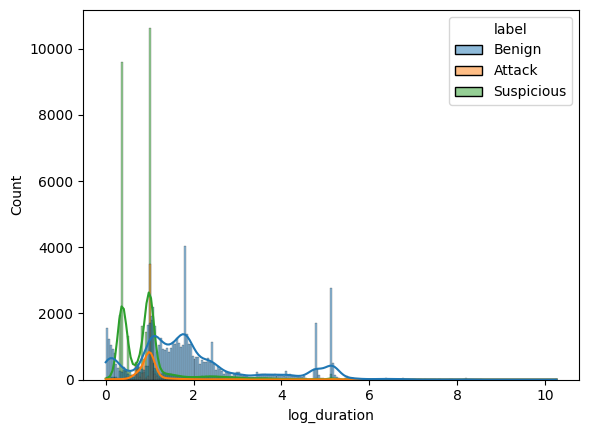

In [ ]:
sns.histplot(
    data=df_semantic,
    x="log_duration",
    hue="label",
    kde=True
)
plt.show()

Доброякісні підключення мають кілька режимів поведінки і мультимодальну структуру. Атаки мають вузький ("гострий") розподіл. Підозрілому типу підключень характерні концентровані короткотривалі сесії.

packets_count -- кількість пакетів даних

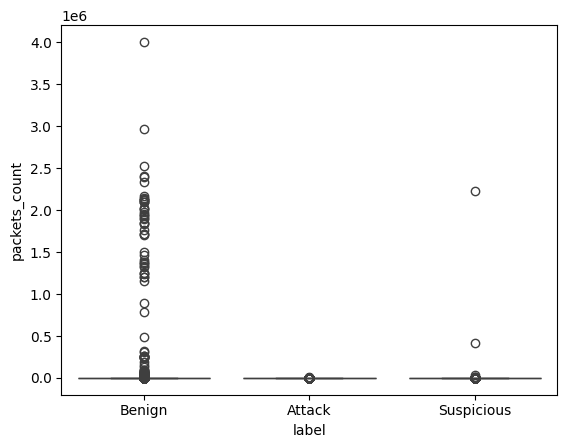

In [ ]:
sns.boxplot(data=df_semantic, x="label", y="packets_count")
plt.show()

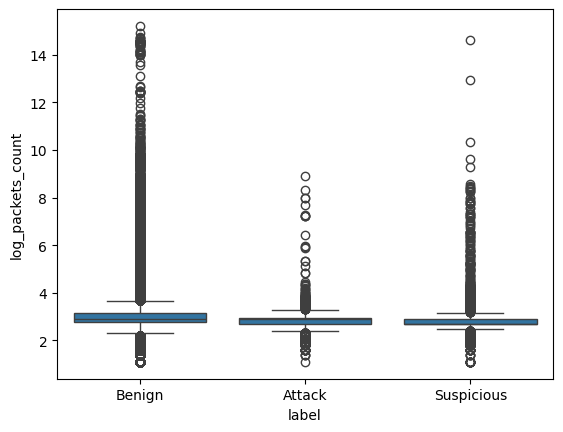

In [ ]:
df_semantic["log_packets_count"] = np.log1p(df_semantic["packets_count"])

sns.boxplot(data=df_semantic, x="label", y="log_packets_count")
plt.show()

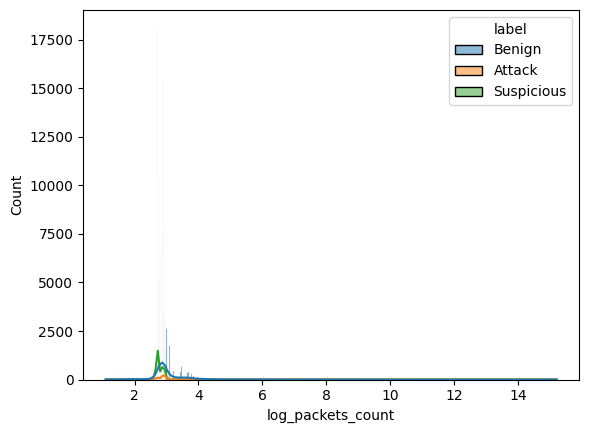

In [ ]:
sns.histplot(
    data=df_semantic,
    x="log_packets_count",
    hue="label",
    kde=True
)
plt.show()

З візуального аналізу розподілів фічі видно значний overlap: класи майже сидять один на одному (особливо Attack і Suspicious). Тому ця фіча стає валідним кандидатом на видалення з фінального датасету

payload_bytes_mean -- це середній розмір payload (корисного навантаження) у потоці. Ця фіча описує "форму" трафіку, характер взаємодії і середній розмір передачі.

Малий payload_mean характерний для:
* ping-like behavior;
* auth attempts;
* probes.

Великий payload_mean_характерний для:
* uploads;
* downloads;
* file transfer.

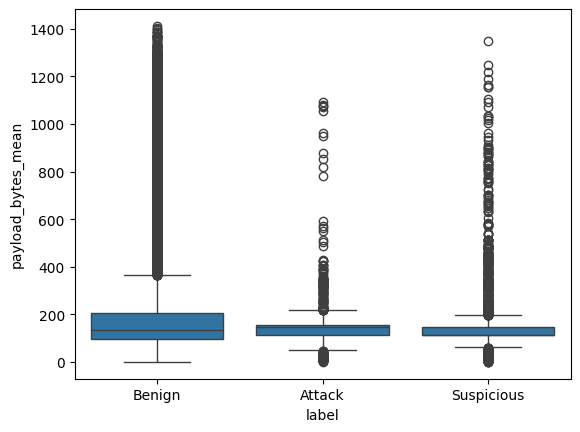

In [ ]:
sns.boxplot(data=df_semantic, x="label", y="payload_bytes_mean")
plt.show()

| Benign | Attack | Suspicious |
|---|---|---|
|Найширший розподіл | Дуже компактний | Середній між ними|
| Великі хвости | Вузький діапазон | Великий правий хвіст|

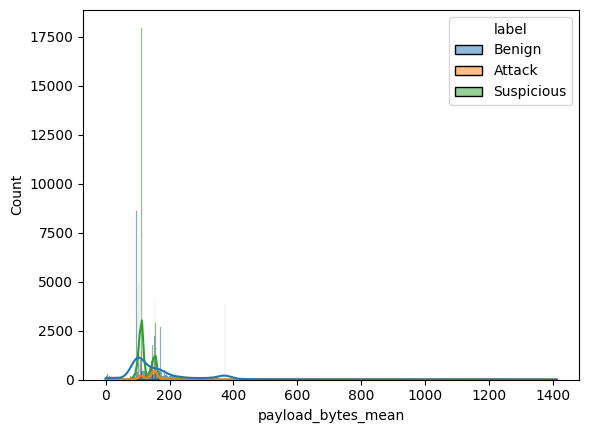

In [ ]:
sns.histplot(
    data=df_semantic,
    x="payload_bytes_mean",
    hue="label",
    kde=True
)
plt.show()

* Attack -> вузький пік
* Suspicious -> зміщений і гостріший
* Benign -> широкий і хаотичний розподіл

payload_bytes_std -- стандартне відхилення розміру payload. Тобто наскільки сильно змінювалися об'єми переданих даних усередині сесії.

Малі значення payload_bytes_std характерні для:
* автоматизованого трафіку;
* скриптів;
* шаблонних запитів.

Великі значення payload_bytes_std притаманні:
* mixed uploads/downloads;
* діям реального користувача.

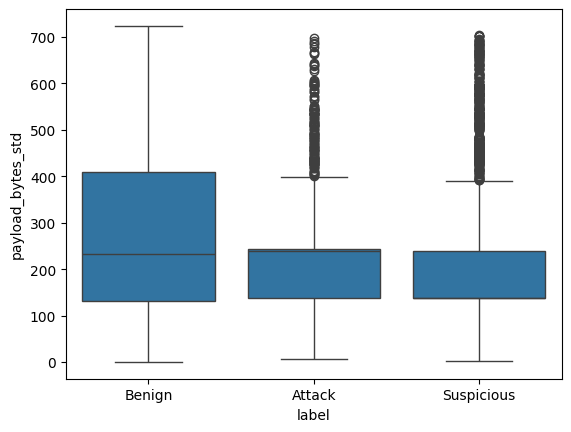

In [ ]:
sns.boxplot(data=df_semantic, x="label", y="payload_bytes_std")
plt.show()

| Benign | Attack | Suspicious |
|---|---|---|
|Найширший розподіл|Значно компактніший|Теж більш концентрований|
|Найбільша дисперсія|Більш структурований|має long-tail|

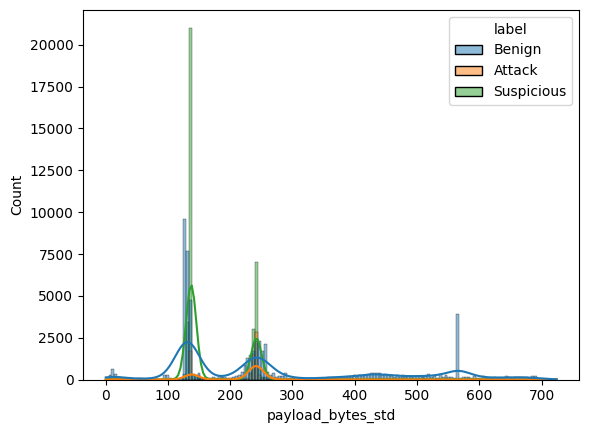

In [ ]:
sns.histplot(
    data=df_semantic,
    x="payload_bytes_std",
    hue="label",
    kde=True
)
plt.show()

* Benign -> мультимодальний хаос
* Attack -> більш вузькі розподіли
* Suspicious -> дуже гострі піки

payload_bytes_skewness -- асиметрія розподілу розмірів payload усередині сесії. Формально вона описує, чи є у рамках сесії більшість payload маленькі, але при цьому кілька дуже великих або навпаки. Звичайний користувач може читати метадані, відкривати малі файли, інколи качати великі, і тому ймовірність асиметрії більша на відміну від нетипової поведінки однотипних запитів.

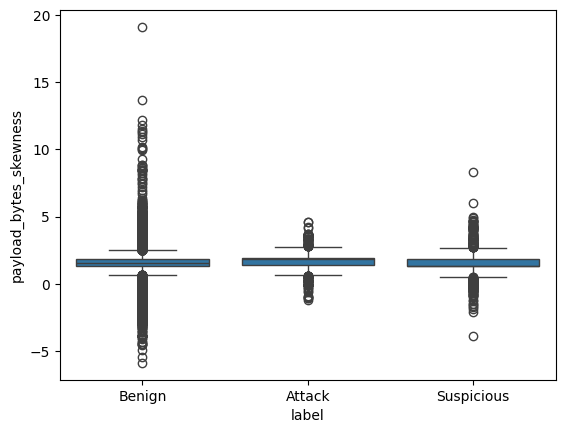

In [ ]:
sns.boxplot(data=df_semantic, x="label", y="payload_bytes_skewness")
plt.show()

| Benign | Attack | Suspicious |
|---|---|---|
|Широкі хвости| Вузький розподіл | Щось середнє між ними|
|Найбільша варіативність|Низька дисперсія|Середнє розсіювання значень|

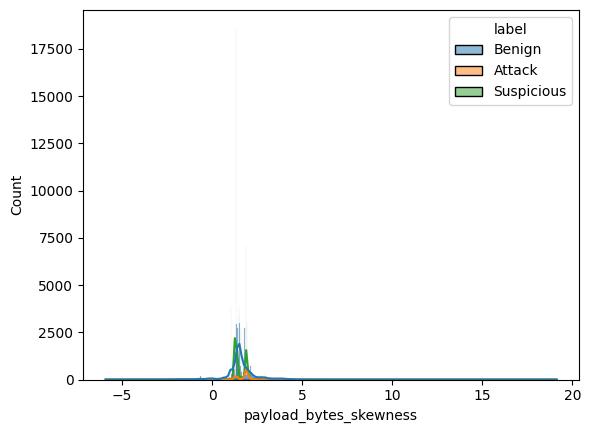

In [ ]:
sns.histplot(
    data=df_semantic,
    x="payload_bytes_skewness",
    hue="label",
    kde=True
)
plt.show()

З порівняльного аналізу гістограм видно, що сигнал не такий сильний, як у bytes_rate, duration чи payload_bytes_std, але у якості lower priority і ця фіча годиться

active periods -- це проміжки часу, коли flow активно передає пакети без довгих пауз.

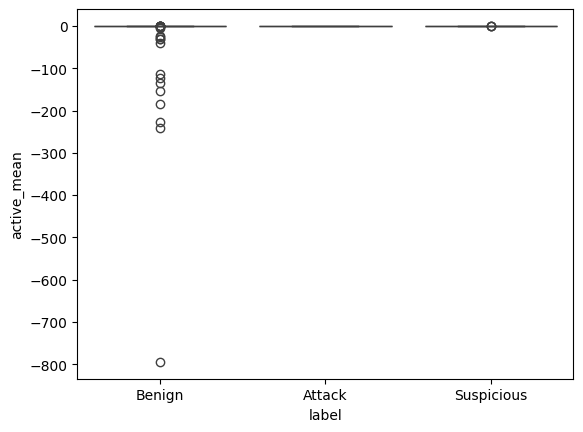

In [ ]:
sns.boxplot(data=df_semantic, x="label", y="active_mean")
plt.show()

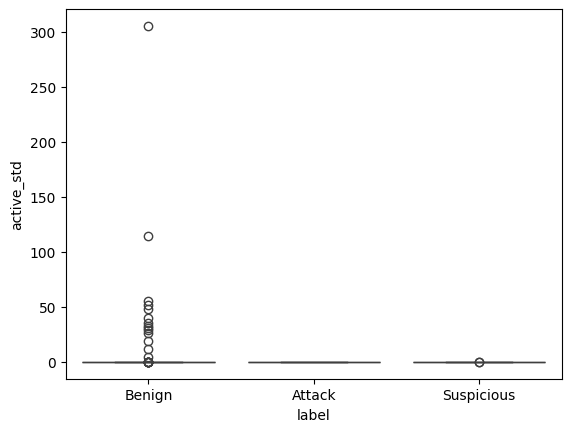

In [ ]:
sns.boxplot(data=df_semantic, x="label", y="active_std")
plt.show()

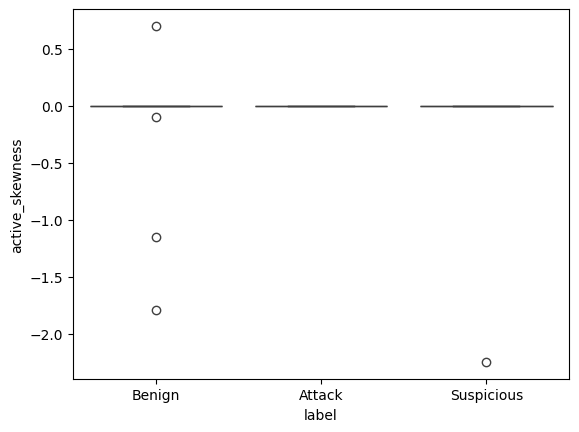

In [ ]:
sns.boxplot(data=df_semantic, x="label", y="active_skewness")
plt.show()

Майже усі flows короткі, і тому active_* ~ 0. Тому рішення видалити цей кластер фіч з датасету прибере network-specific artifacts, і система від цього стане тільки більш чистішою, пояснювальнішою і ближчою до cloud-behavior modeling.

idle_* характеризують паузи без активності всередині мережевого потоку або сесії.

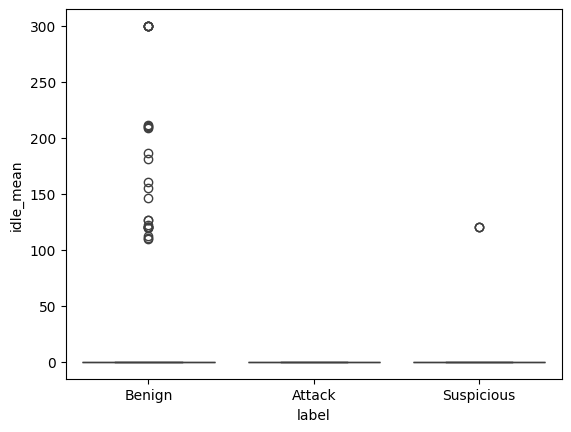

In [ ]:
sns.boxplot(data=df_semantic, x="label", y="idle_mean")
plt.show()

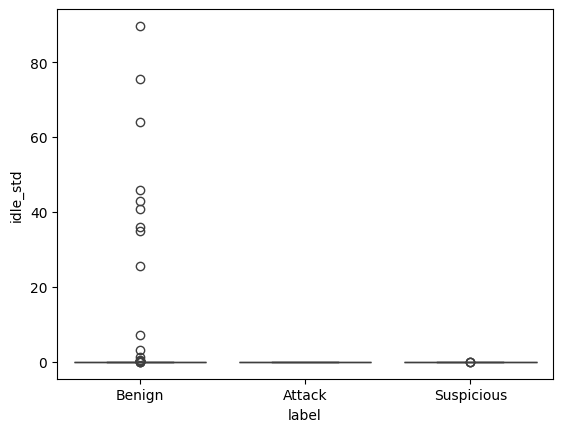

In [ ]:
sns.boxplot(data=df_semantic, x="label", y="idle_std")
plt.show()

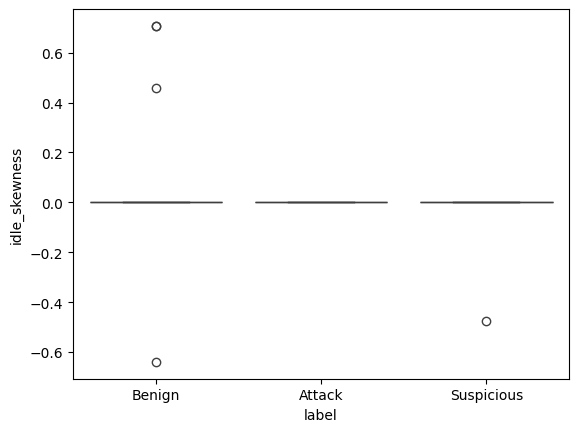

In [ ]:
sns.boxplot(data=df_semantic, x="label", y="idle_skewness")
plt.show()

Ознаки idle_* також характеризуються дуже низькою варіативністю та майже повною концентрацією значень поблизу нуля. Аналіз показав відсутність стабільного поведінкового сигналу для розділення класів. Тому ознаки idle_* були виключені з подальшого аналізу.

down_up_rate -- це фіча відношення download bytes до upload bytes. Теоретично високе значення фічі характерне для типових дій користувача з завантаження даних, натомість низький down_up_rate більше притаманний роботі автоматизованих скриптів з flood чи spam uploads.

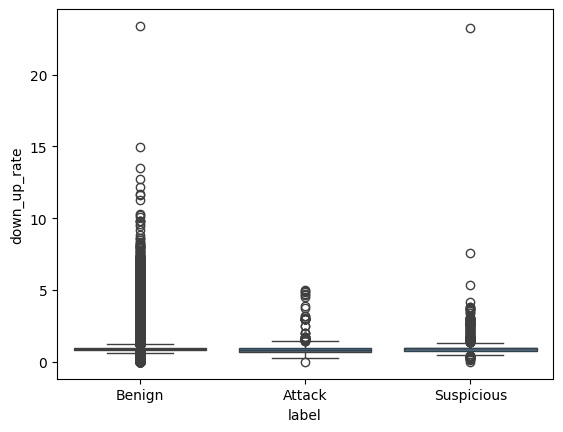

In [ ]:
sns.boxplot(data=df_semantic, x="label", y="down_up_rate")
plt.show()

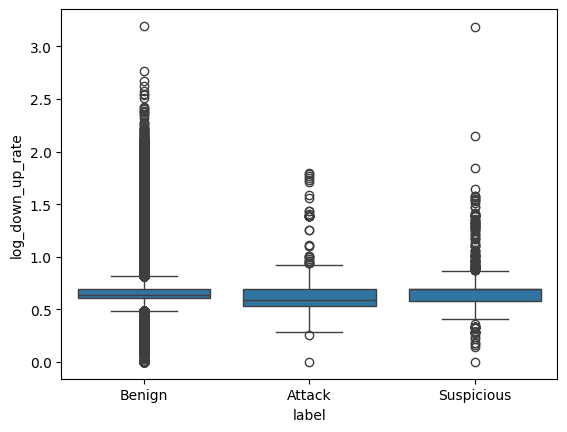

In [ ]:
df_semantic["log_down_up_rate"] = np.log1p(df_semantic["down_up_rate"])

sns.boxplot(data=df_semantic, x="label", y="log_down_up_rate")
plt.show()

Усі три класи досить близькі, медіани і IQR's майже однакові.

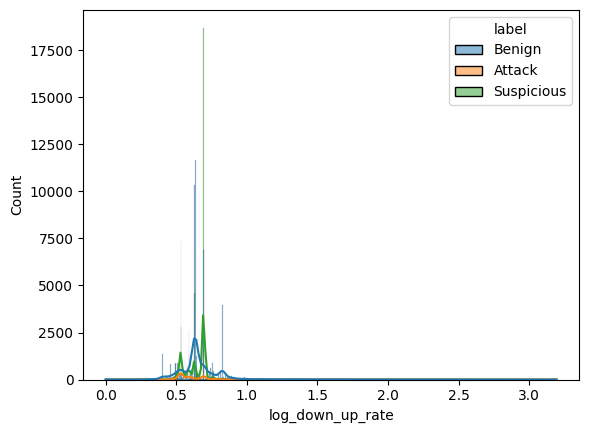

In [ ]:
sns.histplot(
    data=df_semantic,
    x="log_down_up_rate",
    hue="label",
    kde=True
)
plt.show()

Спостерігається сильний overlap між класами, але Suspicious виглядає дещо інакше: має іншу форму з гострішими піками розподілу. Тобто її можна лишити у якості auxiliary feature, а не як core discriminator.

Final Feature Set Description

Після проведення кореляційного аналізу, аналізу розподілів,перевірки поведінкової інформативності та оцінки можливості
відтворення ознак у симуляційному хмарному середовищі
було сформовано фінальний набір ознак для навчання моделі.

Із набору були виключені:
* низькорівневі TCP-ознаки;
* сильно корельовані ознаки;
* ознаки з низькою варіативністю;
* ознаки, які складно або неможливо відтворити у прикладному cloud-середовищі.

Фінальний набір ознак орієнтований на поведінковий аналіз сесій доступу до хмарного сховища.

In [ ]:
final_features = [
    "log_duration",
    "log_bytes_rate",
    "payload_bytes_mean",
    "payload_bytes_std",
    "payload_bytes_skewness",
    "log_down_up_rate"
]

#Feature Explanations

##log_duration
Логарифмована тривалість сесії.
Характеризує часову поведінку користувача та дозволяє
виявляти аномально короткі або надмірно довгі сесії.

## log_bytes_rate
Логарифмована швидкість передачі даних.
Відображає інтенсивність обміну даними у межах сесії.

## payload_bytes_mean
Середній розмір корисного навантаження (payload) у межах сесії.
Характеризує типову структуру переданих даних.

## payload_bytes_std
Стандартне відхилення розміру payload. Описує неоднорідність та варіативність переданих даних у межах сесії.

## payload_bytes_skewness
Асиметрія розподілу payload. Використовується для оцінки форми розподілу переданих даних та виявлення аномальних патернів активності.

## down_up_rate
Співвідношення download/upload активності. Характеризує напрямок передачі даних та може вказувати на аномальну поведінку, пов’язану з масовим завантаженням або вивантаженням даних.

In [ ]:
print("Final features:")
for feature in final_features:
    print("-", feature)

Final features:
- log_duration
- log_bytes_rate
- payload_bytes_mean
- payload_bytes_std
- payload_bytes_skewness
- down_up_rate


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df_model = df_semantic.copy()

df_model["log_duration"] = np.log1p(df_model["duration"])
df_model["log_bytes_rate"] = np.log1p(df_model["bytes_rate"])
df_model["log_down_up_rate"] = np.log1p(df_model["down_up_rate"])

final_features = [
    "log_duration",
    "log_bytes_rate",
    "payload_bytes_mean",
    "payload_bytes_std",
    "payload_bytes_skewness",
    "log_down_up_rate"
]

X = df_model[final_features]
y = df_model["label"]

print("X shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

X shape: (109426, 6)
Target distribution:
label
Benign        63330
Suspicious    38417
Attack         7679
Name: count, dtype: int64


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", list(label_encoder.classes_))

Classes: ['Attack', 'Benign', 'Suspicious']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (87540, 6)
Test shape: (21886, 6)


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       min_samples_split=5, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

Accuracy: 0.8707849766974322
Precision: 0.8770274627867146
Recall: 0.8707849766974322
F1-score: 0.8730716486274814

Classification report:
              precision    recall  f1-score   support

      Attack       0.43      0.53      0.48      1536
      Benign       0.95      0.96      0.95     12666
  Suspicious       0.85      0.79      0.82      7684

    accuracy                           0.87     21886
   macro avg       0.74      0.76      0.75     21886
weighted avg       0.88      0.87      0.87     21886



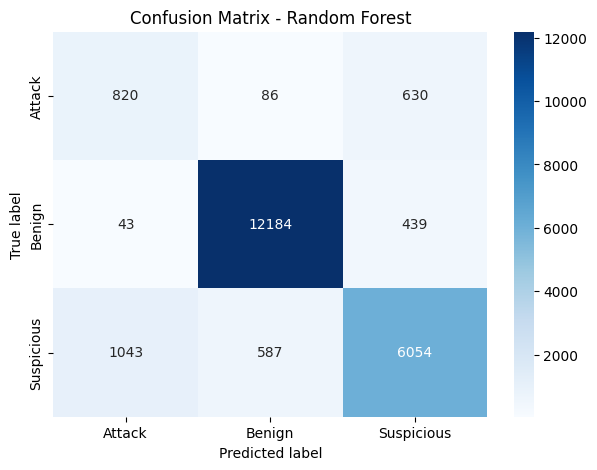

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

log_duration              0.296812
log_bytes_rate            0.273546
payload_bytes_std         0.153603
payload_bytes_mean        0.122524
payload_bytes_skewness    0.098112
log_down_up_rate          0.055402
dtype: float64


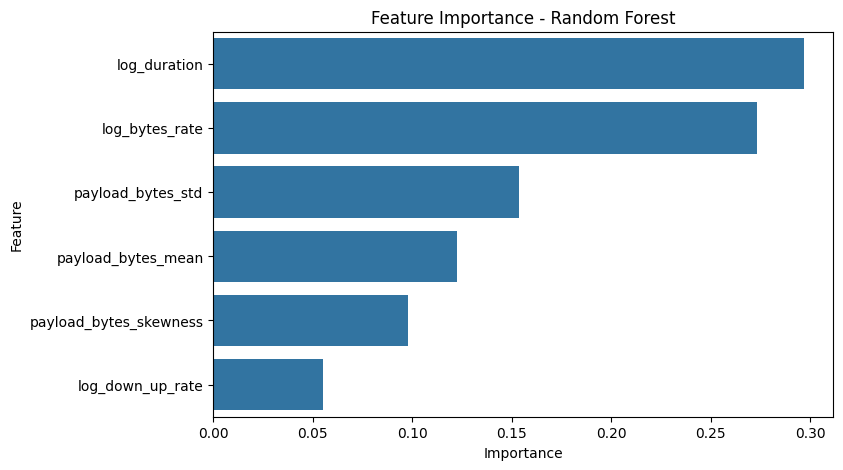

In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=final_features
).sort_values(ascending=False)

print(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
final_columns = final_features.copy()
final_columns.append('label')
df_semantic[final_columns].to_csv('new_df.csv', index=False)

In [ ]:
import joblib

joblib.dump(rf_model, "rf_cloud_ids.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']